# ⚔️ Analisi delle partite della competizione — PTCG AI Battle

Analizza il **DB delle partite** costruito da `competiotion_scraper.py` a partire dai replay
degli episodi Kaggle: classifica degli agent, scontri diretti, durata delle partite, carte più
presenti nei mazzi e carte più giocate.

**Sorgente dati.** Il notebook usa `ptcg_data/matches.db` (dati reali) se popolato; altrimenti
ripiega su `ptcg_data/matches_demo.db` (**dati sintetici**, fallback offline). In cima all'output
c'è un banner che indica quale DB è in uso.

> I dati reali si ottengono **senza credenziali** (endpoint pubblici Kaggle):
> `python competiotion_scraper.py scrape --teams 15 --episodes 8` e riesegui questo notebook.


In [2]:
import sys, sqlite3, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import meta_utils as mu
import competiotion_scraper as scr

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
PAL = plt.get_cmap("tab10").colors

def save(fig, name):
    fig.savefig(mu.FIG_DIR / f"03_{name}.png", bbox_inches="tight", dpi=130)

def pick_db():
    real, demo = scr.DB_PATH, scr.DEMO_DB_PATH
    if real.exists():
        n = sqlite3.connect(real).execute("select count(*) from matches").fetchone()[0]
        if n > 0:
            return real, False
    if not demo.exists():
        print("Nessun DB trovato: genero quello dimostrativo...")
        scr.make_demo_db()
    return demo, True

DB_PATH, IS_DEMO = pick_db()
conn = sqlite3.connect(DB_PATH)
matches = pd.read_sql("select * from matches", conn)
decks   = pd.read_sql("select * from match_decks", conn)
plays   = pd.read_sql("select * from cards_played", conn)

banner = ("⚠️  DATI DIMOSTRATIVI (sintetici) — esegui lo scraper con le credenziali Kaggle per i dati reali."
          if IS_DEMO else "✅  Dati reali dal DB delle partite.")
print("="*90); print(banner); print("DB:", DB_PATH.name, "| partite:", len(matches)); print("="*90)
matches.head(3)

✅  Dati reali dal DB delle partite.
DB: matches.db | partite: 8624


,episode_id,agent0,agent1,reward0,reward1,winner_idx,n_steps,n_plays,scraped_at
0,88062288,LiamK,Azat Akhtyamov,-1.0,1.0,1.0,122,103,2026-07-25T13:35:03+00:00
1,88061084,Brahim,Azat Akhtyamov,-1.0,1.0,1.0,92,89,2026-07-25T13:35:06+00:00
2,88060456,me and the lads,Azat Akhtyamov,1.0,-1.0,0.0,214,105,2026-07-25T13:35:08+00:00


## 1. Panoramica
Numero di partite, agent coinvolti, distribuzione delle vittorie.

In [3]:
agents = sorted(set(matches["agent0"]) | set(matches["agent1"]))
print(f"Partite: {len(matches)} | Agent distinti: {len(agents)}")
print("Agent:", ", ".join(agents))
n_draw = int((matches["winner_idx"].isna()).sum())
print(f"Partite senza vincitore (draw/errore): {n_draw}")
matches["n_steps"].describe().to_frame("n_steps").T

Partite: 8624 | Agent distinti: 1346
Agent: (ノ◡ <), 20241206_yujinkim, 213tubo, 3.14159265, 5.5, 600626_วายุ, @🤞@, A. R. SEKKAT, AGNT.gg, AI部, AKIYA NAKASATO, AL Najafi, ANIMA SQUAD, ASAGAO, ASH, Aakansha.aakaa, Aayush Sigdel, Abdalrahman mohamed, Abdul Rauf, Abdulazeez AbdulMumeen, Abhiraj Singh, Abhishek Jain, Abhyuday, Adastra, Adi Kumar, Adi Kusuma, Aditya Sasidhar, Aditya Sharma, AdityaKrishnamurthy, AdrianWang2003, Agustín Arellano, Aikimi, Ajishio, Akasamai, Akhyar Safrudin, Akifumi Okubo, Akio Furutsuka, Akira-Ninth, AkiraIshikawa, Akito Maruo, Albert Wang, Alejandro Espinoza, Alex, Alex G, Alex Gorica, Alexandru Tanasel, AliLucky, Allan Kássio Beckman Soares da Cruz, Allgea, AlphaKarpZero, AlphaMon, Altar Buyukdogan, Alvin_Lee, AmiciDelPo, Amon Suzuki, AnSuSu, Andreas Bretschneider, Andreas Palmgren, Andrej Carpenter, Andrew Kuo, AndyLiuHz, Angus Chang, Anhad Mahajan, Ant, Anthony Guerrera, Anthony Toffetti, Anvith Pothula, Aphrodite, Arctix0, Arda Karakaş, Ardell Aghna Mahend

,count,mean,std,min,25%,50%,75%,max
n_steps,8624.0,161.026902,88.282423,13.0,136.0,162.0,186.0,6003.0


## 2. Classifica degli agent
Winrate, partite giocate e un **Elo** semplice (calcolato scorrendo le partite in ordine).

,agent,partite,vittorie,winrate,elo
0,szlachetny snieg,153,101,0.660131,1221
1,Majkel1337,312,190,0.608974,1193
2,matheus,109,72,0.660550,1185
3,ktr,132,79,0.598485,1182
4,Dominic Peel,178,108,0.606742,1181
5,213tubo,172,104,0.604651,1171
6,Pokemon Siuuuu,114,65,0.570175,1166
7,junseo lee,128,80,0.625000,1164
8,LumenLiquidity,125,82,0.656000,1163
9,Iliamna,127,81,0.637795,1155


Giocatori con >= 3 partite: 370 (grafico: top 20)


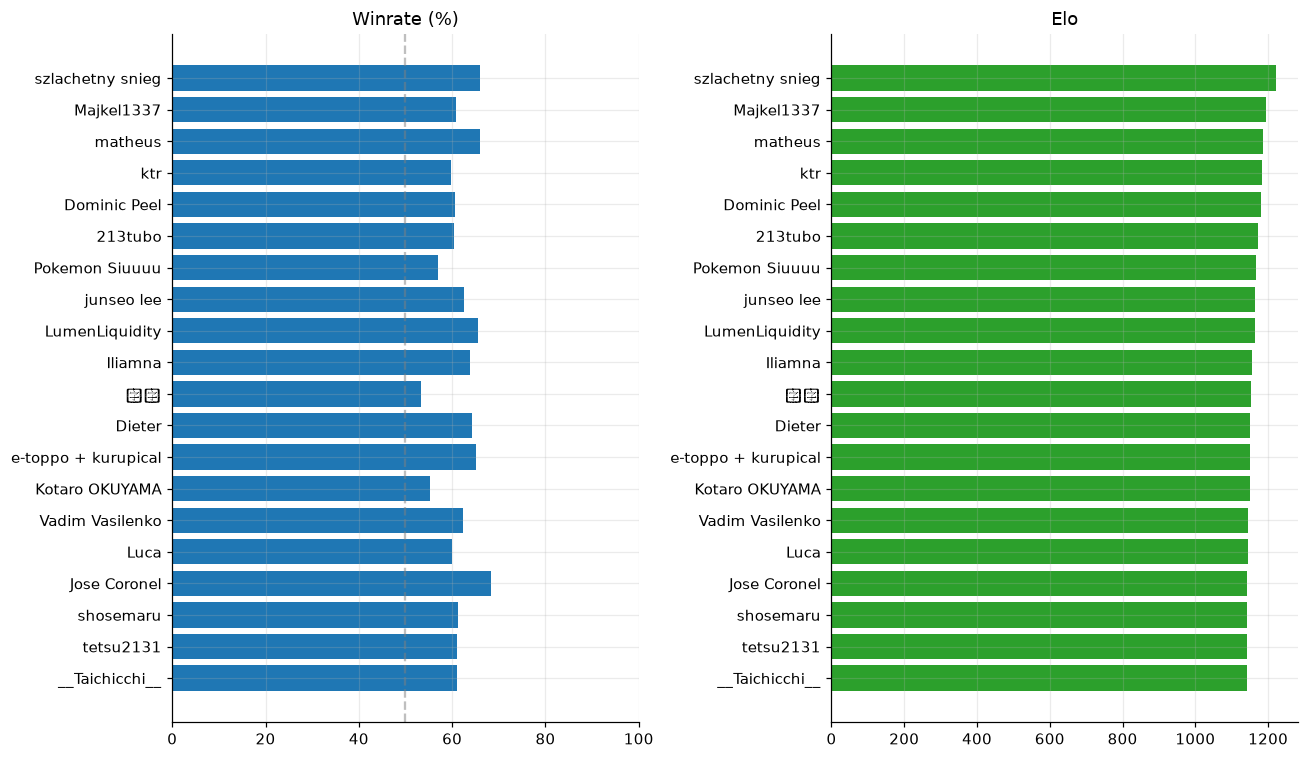

In [4]:
def standings(matches):
    rec = {a: {"g":0,"w":0,"elo":1000.0} for a in agents}
    K = 24
    for _, m in matches.iterrows():
        a0, a1, w = m["agent0"], m["agent1"], m["winner_idx"]
        if pd.isna(w):
            continue
        for a in (a0, a1): rec[a]["g"] += 1
        winner, loser = (a0, a1) if w == 0 else (a1, a0)
        rec[winner]["w"] += 1
        ew = 1/(1+10**((rec[loser]["elo"]-rec[winner]["elo"])/400))
        rec[winner]["elo"] += K*(1-ew); rec[loser]["elo"] -= K*(1-ew)
    df = pd.DataFrame([{"agent":a, "partite":v["g"], "vittorie":v["w"],
                        "winrate": v["w"]/v["g"] if v["g"] else 0, "elo": round(v["elo"])}
                       for a,v in rec.items()])
    return df.sort_values(["elo","winrate"], ascending=False).reset_index(drop=True)

table = standings(matches)
display(table.head(25))

# Nei dati reali ci sono molti giocatori con pochissime partite: per i grafici tengo
# solo chi ha giocato abbastanza da rendere winrate/Elo informativi.
MIN_GAMES = 3 if not IS_DEMO else 1
sig = table[table["partite"] >= MIN_GAMES].sort_values("elo", ascending=False).head(20)
print(f"Giocatori con >= {MIN_GAMES} partite: {len(table[table['partite']>=MIN_GAMES])} (grafico: top {len(sig)})")
if len(sig):
    fig, ax = plt.subplots(1, 2, figsize=(12, max(3, .35*len(sig))))
    t = sig.iloc[::-1]
    ax[0].barh(t["agent"], t["winrate"]*100, color=PAL[0]); ax[0].set_title("Winrate (%)"); ax[0].set_xlim(0,100)
    ax[0].axvline(50, ls="--", color="grey", alpha=.5)
    ax[1].barh(t["agent"], t["elo"], color=PAL[2]); ax[1].set_title("Elo")
    save(fig, "standings"); plt.show()
table.to_csv(mu.DATA_DIR / "matches_standings.csv", index=False)

## 3. Scontri diretti (head-to-head)
Matrice delle vittorie tra i giocatori più attivi (riga = agente, colonna = avversario,
valore = % vittorie della riga). Limitata ai top per numero di partite per restare leggibile.

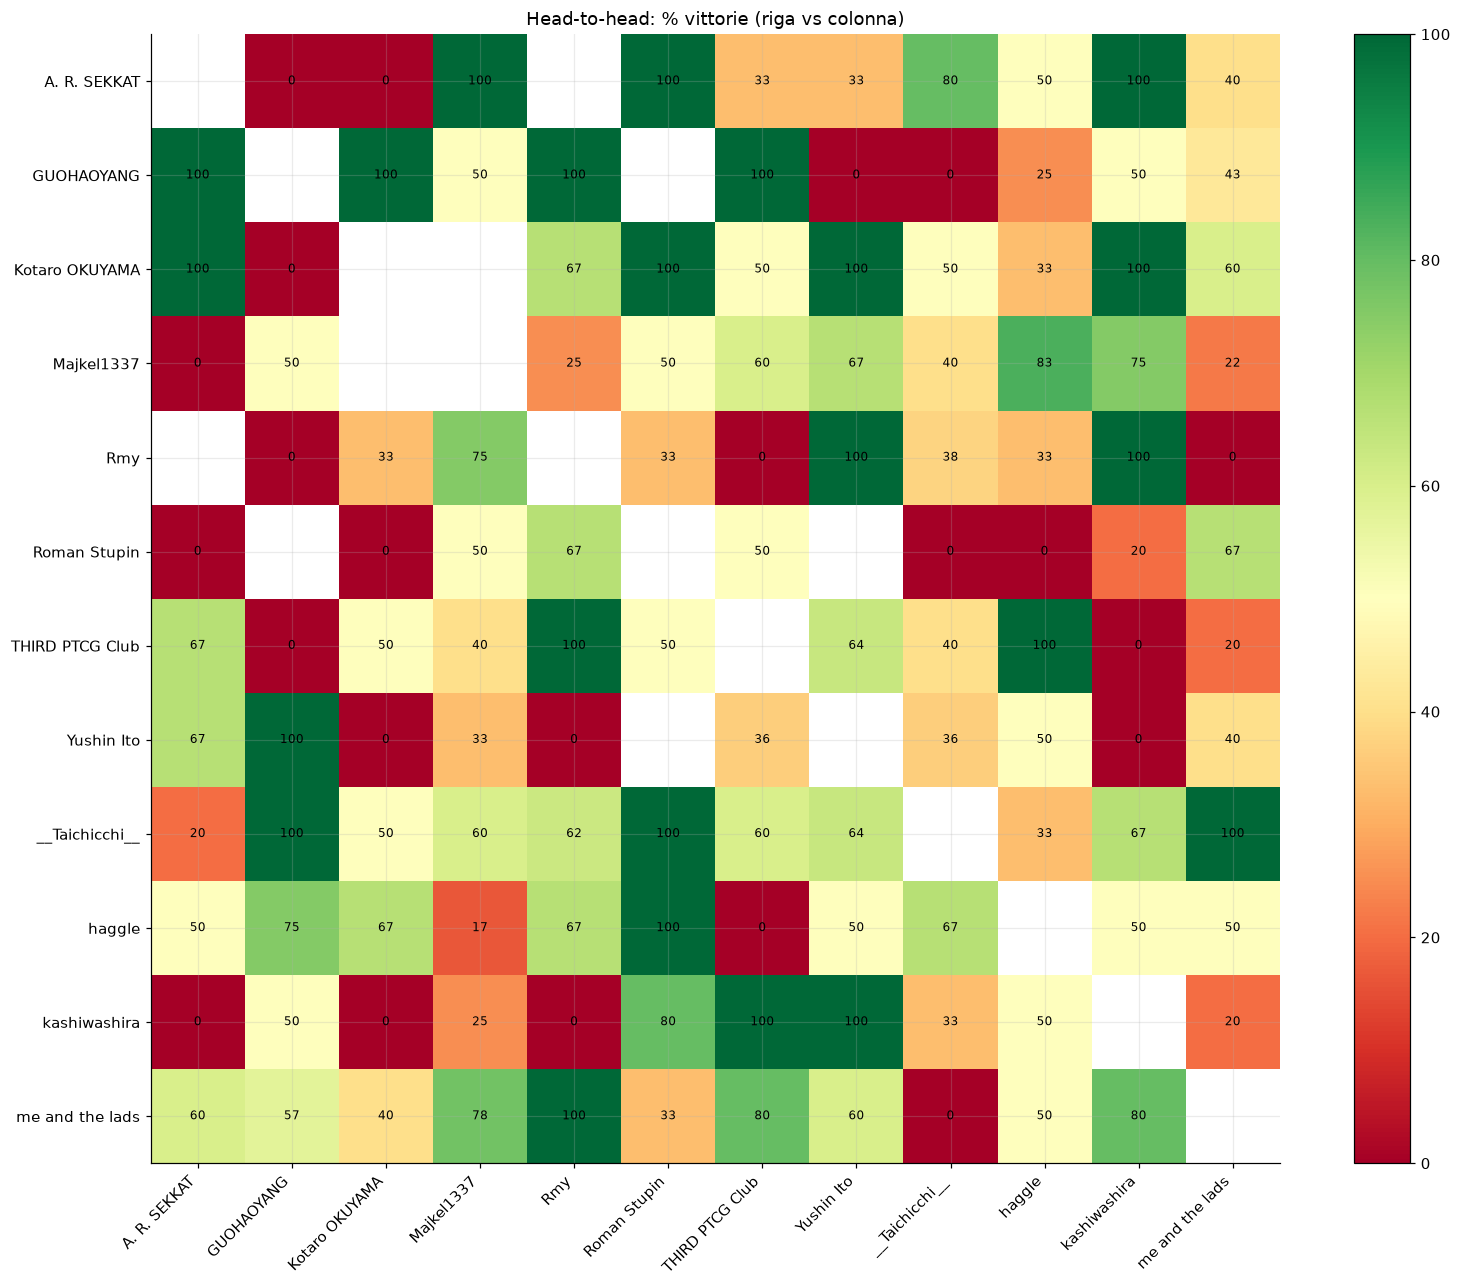

In [5]:
H2H_TOP = 12
active = table.sort_values("partite", ascending=False).head(H2H_TOP)["agent"].tolist()
hagents = [a for a in agents if a in active]
h2h = pd.DataFrame(np.nan, index=hagents, columns=hagents)
cnt = {(a,b):[0,0] for a in hagents for b in hagents}
for _, m in matches.iterrows():
    if pd.isna(m["winner_idx"]): continue
    a0,a1 = m["agent0"], m["agent1"]
    if (a0,a1) not in cnt: continue
    w = int(m["winner_idx"])
    cnt[(a0,a1)][0]+=1; cnt[(a1,a0)][0]+=1
    if w==0: cnt[(a0,a1)][1]+=1
    else:    cnt[(a1,a0)][1]+=1
for a in hagents:
    for b in hagents:
        g,win = cnt[(a,b)]
        if a!=b and g>0: h2h.loc[a,b] = 100*win/g

if len(hagents) >= 2:
    fig, ax = plt.subplots(figsize=(1.0*len(hagents)+2, 0.9*len(hagents)+1))
    im = ax.imshow(h2h.values.astype(float), cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_xticks(range(len(hagents))); ax.set_xticklabels(hagents, rotation=45, ha="right")
    ax.set_yticks(range(len(hagents))); ax.set_yticklabels(hagents)
    for i in range(len(hagents)):
        for j in range(len(hagents)):
            v = h2h.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=8)
    ax.set_title("Head-to-head: % vittorie (riga vs colonna)")
    plt.colorbar(im, ax=ax, fraction=.046); save(fig, "head_to_head"); plt.show()
else:
    print("Troppi pochi giocatori con partite multiple per una matrice head-to-head.")

## 4. Durata delle partite
Numero di step per partita: proxy di quanto sono lunghe/combattute.

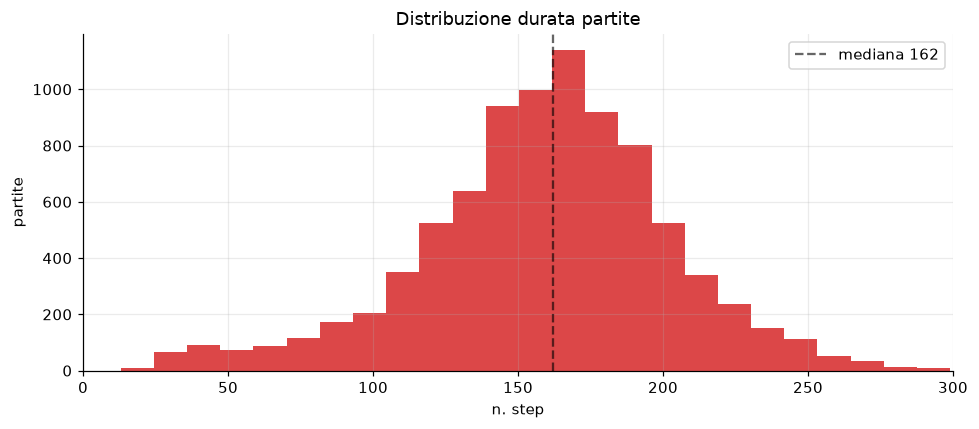

In [11]:
steps = matches["n_steps"].dropna()
max_step = 300
steps = steps[(steps >= 0) & (steps <= max_step )]

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(steps, bins=25, color=PAL[3], alpha=.85)

ax.set_xlim(0, max_step )
ax.set_xlabel("n. step")
ax.set_ylabel("partite")
ax.set_title("Distribuzione durata partite")

ax.axvline(steps.median(), ls="--", color="k", alpha=.6,
           label=f"mediana {steps.median():.0f}")

ax.legend()
save(fig, "match_length")
plt.show()

## 5. Carte più presenti nei mazzi
Aggregate su tutti i mazzi visti nelle partite (pesate per numero di copie). Arricchite con
categoria/tipo dal card pool della competizione.

,card_id,card_name,copie_totali,tipo,categoria
0,7,Basic {D} Energy,73033,{D},Energy
1,1152,Poké Pad,62209,,Trainer
2,1086,Buddy-Buddy Poffin,60043,,Trainer
3,1227,Lillie's Determination,49269,,Trainer
4,1182,Boss’s Orders,36702,,Trainer
5,1079,Rare Candy,34675,,Trainer
6,1097,Night Stretcher,32667,,Trainer
7,1219,Team Rocket's Petrel,29445,,Trainer
8,112,Munkidori,29161,{P},Pokémon
9,1259,Spikemuth Gym,27990,,Trainer


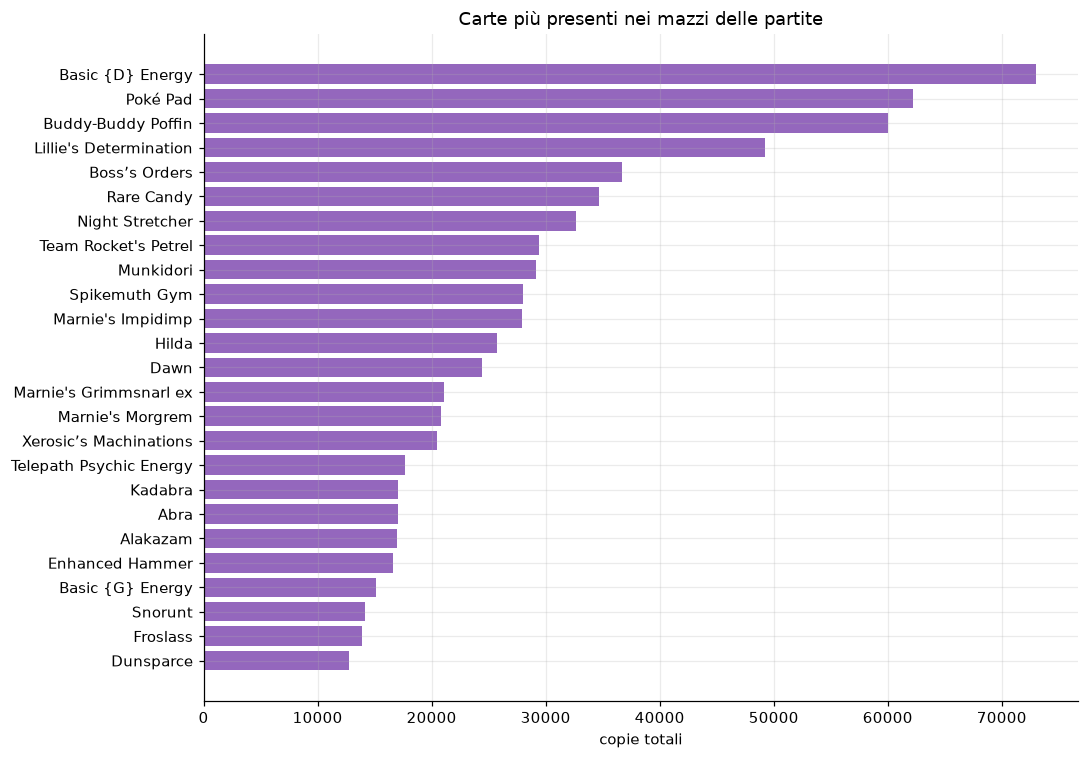

In [7]:
pool = mu.cards_unique(mu.load_cards()).set_index("Card ID")
deck_cards = (decks.groupby(["card_id","card_name"])["copies"].sum()
              .reset_index().rename(columns={"copies":"copie_totali"})
              .sort_values("copie_totali", ascending=False))
deck_cards["tipo"] = deck_cards["card_id"].map(pool["energy_type"]).fillna("")
deck_cards["categoria"] = deck_cards["card_id"].map(
    pool.apply(lambda r: "Pokémon" if r["is_pokemon"] else "Trainer" if r["is_trainer"] else "Energy" if r["is_energy"] else "?", axis=1))
display(deck_cards.head(20).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10,7))
top = deck_cards.head(25).iloc[::-1]
ax.barh(top["card_name"].astype(str), top["copie_totali"], color=PAL[4])
ax.set_title("Carte più presenti nei mazzi delle partite"); ax.set_xlabel("copie totali")
save(fig, "top_deck_cards"); plt.show()
deck_cards.to_csv(mu.DATA_DIR / "matches_top_cards.csv", index=False)

## 6. Carte più giocate durante le partite
Dalla sequenza delle giocate (`cards_played`): quali carte vengono effettivamente calate in campo.

,card_name,card_id,volte_giocata
0,Basic {D} Energy,7,65291
1,Poké Pad,1152,43825
2,Buddy-Buddy Poffin,1086,41389
3,Lillie's Determination,1227,31690
4,Boss’s Orders,1182,26102
5,Marnie's Impidimp,646,25983
6,Rare Candy,1079,24610
7,Munkidori,112,23064
8,Night Stretcher,1097,23000
9,Hilda,1225,19757


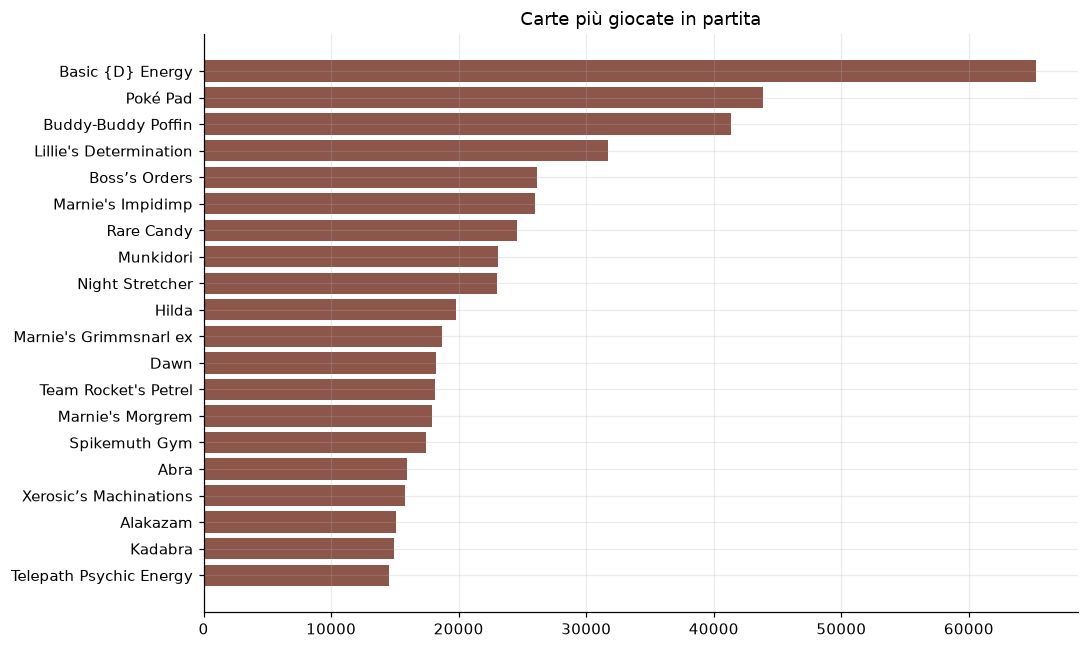

In [8]:
if len(plays):
    pl = (plays.groupby("card_id").size().reset_index(name="volte_giocata"))
    pl["card_name"] = pl["card_id"].map(pool["Card Name"]).fillna(pl["card_id"].astype(str))
    pl = pl.sort_values("volte_giocata", ascending=False)
    display(pl.head(20)[["card_name","card_id","volte_giocata"]].reset_index(drop=True))
    fig, ax = plt.subplots(figsize=(10,6))
    top = pl.head(20).iloc[::-1]
    ax.barh(top["card_name"].astype(str), top["volte_giocata"], color=PAL[5])
    ax.set_title("Carte più giocate in partita"); save(fig, "top_played_cards"); plt.show()
else:
    print("Nessuna giocata registrata (play_sequence vuota nei replay).")

## 7. Profilo dei mazzi per agente (top agent)
Composizione Pokémon / Trainer / Energy del mazzo tipico di ciascun agente — utile per capire
*che tipo di strategia* usa chi vince di più.

,Pokémon,Trainer,Energy
agent,,,
(ノ◡ <),21.7,65.0,13.3
20241206_yujinkim,30.0,53.3,16.7
213tubo,33.2,50.6,16.2
3.14159265,30.0,50.0,20.0
5.5,33.3,55.0,11.7
...,...,...,...
대답해드리는게인지상정,30.2,53.2,16.6
둔갑숨기,31.7,43.3,25.0
서재원,20.0,25.0,55.0


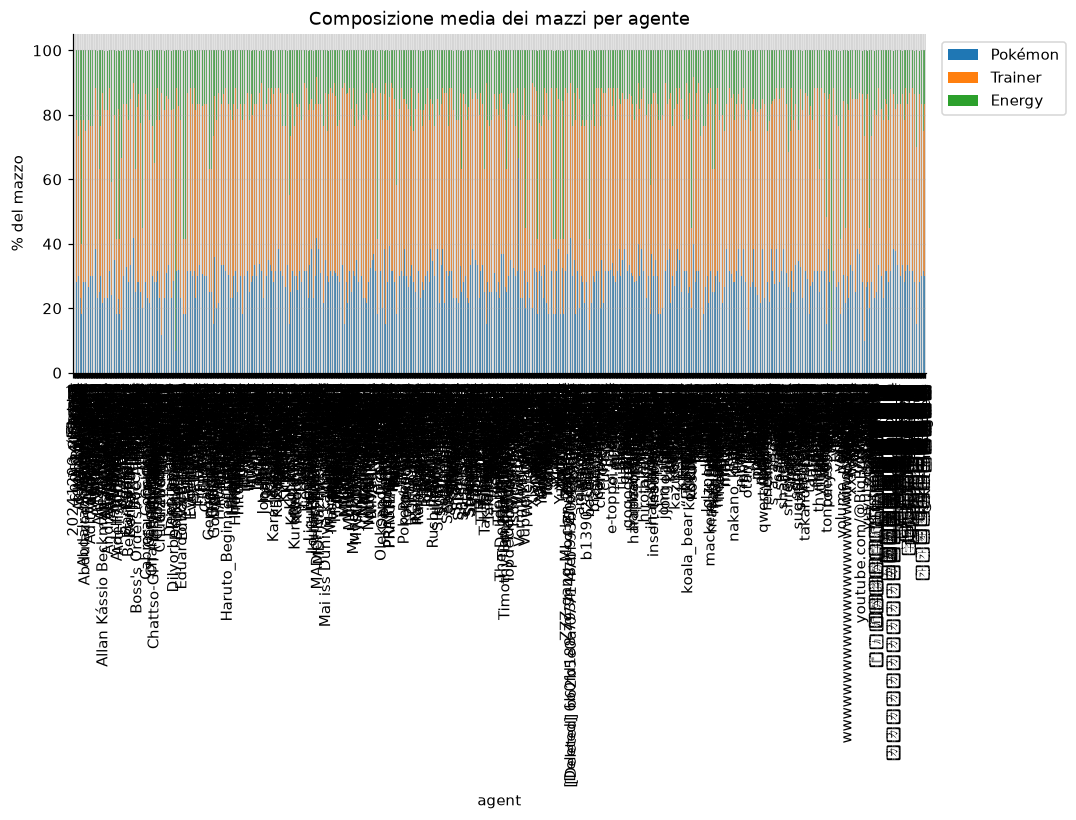

In [9]:
rows=[]
for ag in agents:
    eps = matches[(matches.agent0==ag)]["episode_id"].tolist()
    idxs = [(e,0) for e in eps] + [(e,1) for e in matches[matches.agent1==ag]["episode_id"]]
    d = decks.merge(pd.DataFrame(idxs, columns=["episode_id","player_idx"]), on=["episode_id","player_idx"])
    if d.empty: continue
    d = d.copy()
    d["cat"] = d["card_id"].map(pool.apply(lambda r:"Pokémon" if r["is_pokemon"] else "Trainer" if r["is_trainer"] else "Energy" if r["is_energy"] else "?", axis=1))
    tot = d["copies"].sum()
    g = d.groupby("cat")["copies"].sum()/tot*100
    rows.append({"agent":ag, **{k: round(g.get(k,0),1) for k in ["Pokémon","Trainer","Energy"]}})
prof = pd.DataFrame(rows).set_index("agent")
display(prof)
ax = prof.plot(kind="bar", stacked=True, figsize=(10,4), color=[PAL[0],PAL[1],PAL[2]])
ax.set_ylabel("% del mazzo"); ax.set_title("Composizione media dei mazzi per agente")
ax.legend(bbox_to_anchor=(1.01,1)); save(ax.get_figure(), "agent_deck_profile"); plt.show()

---
### Come popolare il DB con dati reali (nessuna credenziale)
```bash
python competiotion_scraper.py check                          # verifica accesso API pubblica
python competiotion_scraper.py scrape --teams 15 --episodes 8 # popola ptcg_data/matches.db
```
Poi riesegui questo notebook: userà automaticamente i dati reali. I replay grezzi restano in cache
(`ptcg_data/replays/`), quindi un secondo run non riscarica nulla.